In [32]:
import pandas as pd 
df = pd.read_csv(r'C:\Users\rajas\Downloads\amazon_sales_dataset.csv')
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [33]:
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [14]:
print(df[df['price'] <= 0])
print(df[df['quantity_sold'] <= 0])

Empty DataFrame
Columns: [order_id, order_date, product_id, product_category, price, discount_percent, quantity_sold, customer_region, payment_method, rating, review_count, discounted_price, total_revenue]
Index: []
Empty DataFrame
Columns: [order_id, order_date, product_id, product_category, price, discount_percent, quantity_sold, customer_region, payment_method, rating, review_count, discounted_price, total_revenue]
Index: []


In [16]:
df[(df['rating'] < 0) | (df['rating'] > 5)]


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue


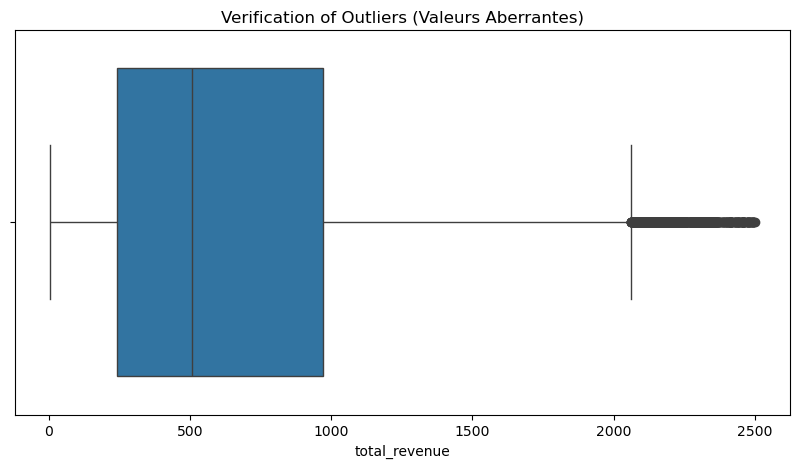

In [40]:
import matplotlib.pyplot as plt  
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['total_revenue'])
plt.title('Verification of Outliers (Valeurs Aberrantes)')
plt.show()

In [41]:

Q1 = df['total_revenue'].quantile(0.25)
Q3 = df['total_revenue'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df['total_revenue'] = df['total_revenue'].clip(upper=upper_bound)

print(f"Outliers capped at: {upper_bound}")

Outliers capped at: 2061.945


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = ['price', 'discount_percent', 'quantity_sold', 'rating', 'total_revenue']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df[cols_to_scale].head()

,price,discount_percent,quantity_sold,rating,total_revenue
0,-0.865289,-0.339137,0.706945,0.436361,-0.368649
1,0.350240,0.676030,1.413465,0.609628,1.069452
2,1.701061,0.676030,-0.706097,1.216065,0.266297
3,0.835123,0.168447,0.706945,1.735868,1.173890
4,-0.355375,-1.354304,0.706945,1.389333,0.292175


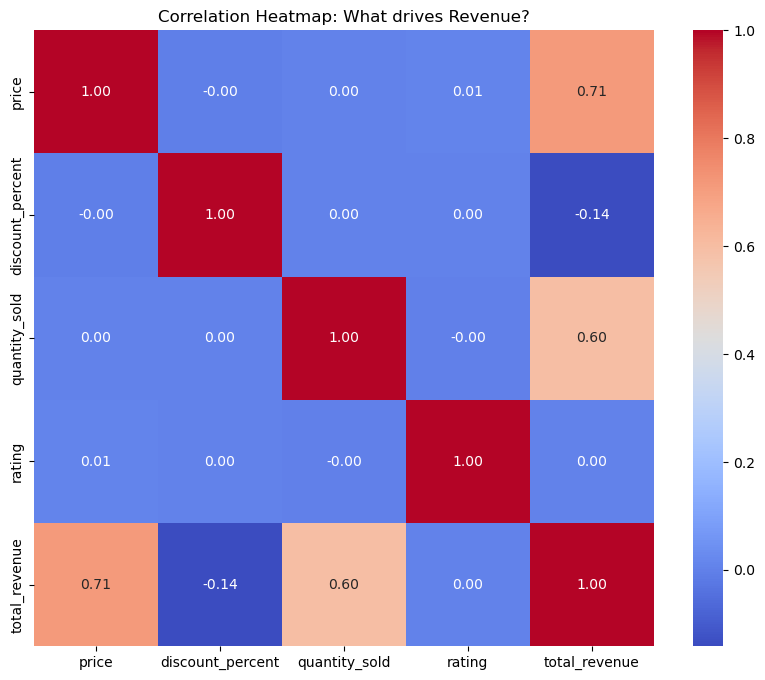

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

correlation_matrix = df[['price', 'discount_percent', 'quantity_sold', 'rating', 'total_revenue']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: What drives Revenue?')
plt.show()

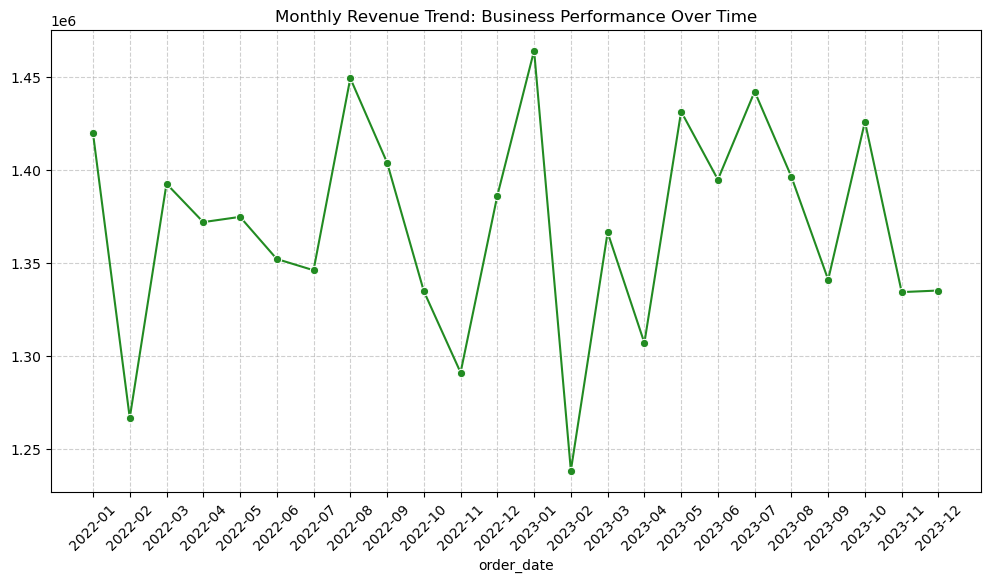

In [36]:

df['order_date'] = pd.to_datetime(df['order_date'])

monthly_revenue = df.groupby(df['order_date'].dt.to_period('M'))['total_revenue'].sum()

monthly_revenue.index = monthly_revenue.index.astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o', color='forestgreen')

plt.title('Monthly Revenue Trend: Business Performance Over Time')
plt.xticks(rotation=45) # Rotates dates so they don't overlap
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

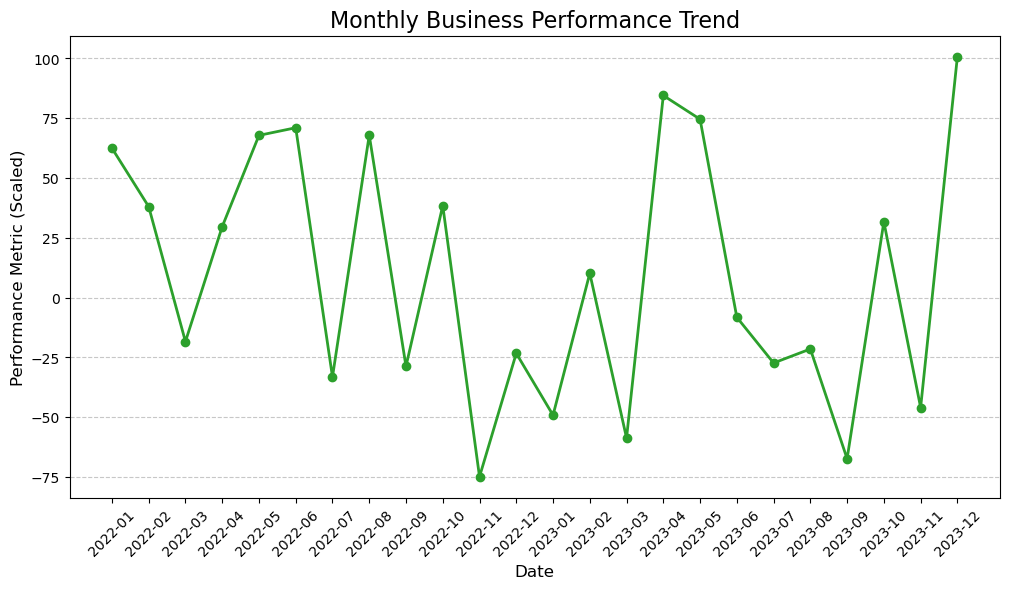

In [44]:

df['relative_revenue'] = df['price'] * df['quantity_sold']

trend_data = df.groupby(df['order_date'].dt.to_period('M'))['relative_revenue'].sum()
trend_data.index = trend_data.index.astype(str)

plt.figure(figsize=(12, 6))
plt.plot(trend_data.index, trend_data.values, marker='o', color='#2ca02c', linewidth=2)

plt.title('Monthly Business Performance Trend', fontsize=16)
plt.ylabel('Performance Metric (Scaled)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\rajas\AppData\Local\Temp\ipykernel_16752\316090071.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


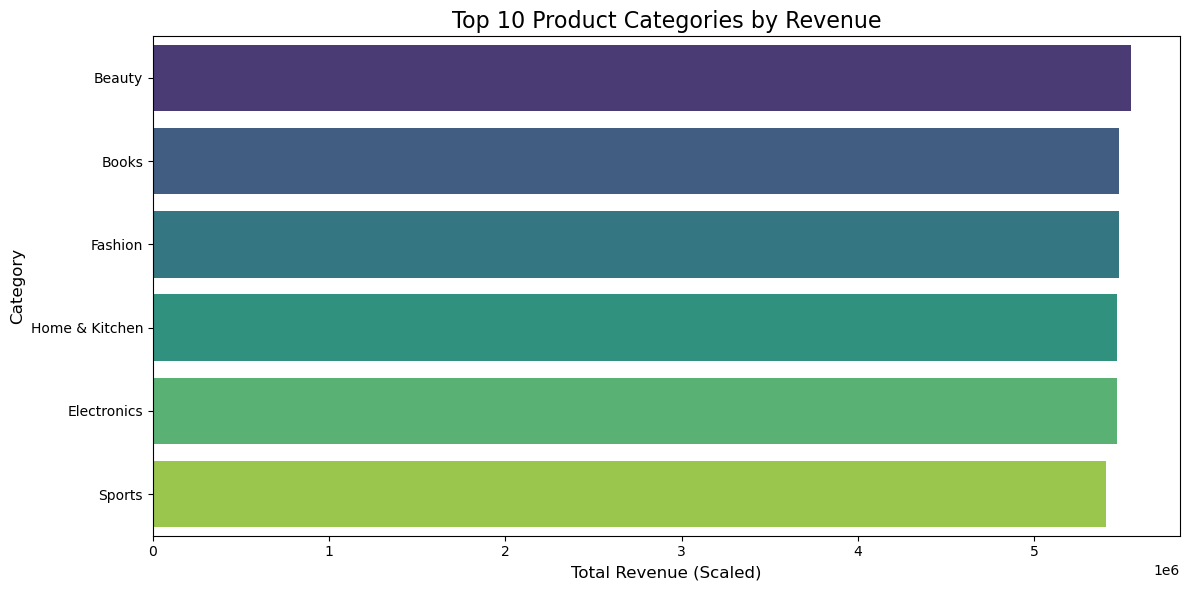

In [38]:

top_categories = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')

plt.title('Top 10 Product Categories by Revenue', fontsize=16)
plt.xlabel('Total Revenue (Scaled)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

In [39]:
# Save the final dataframe to a CSV file
df.to_csv('cleaned_ecommerce_data.csv', index=False)

print("Project Complete! Your cleaned dataset is ready for a portfolio or a Machine Learning model.")

Project Complete! Your cleaned dataset is ready for a portfolio or a Machine Learning model.
